# HCNNG

In [ ]:
# One-time Build HCNNG

cd hcnng
g++ hcnng.cpp -o hcnng -std=c++11 -fopenmp -O3
g++ search.cpp -o search -std=c++11 -fopenmp -O3

In [1]:
import json
import os
import re
import pandas as pd

def extract_hcnng_metrics(
    base_dir: str 
):
    """
    遍历 HCNNG 结果目录（maxcalc_* 子目录），提取每个 max_calc 下的 BEIR 指标和 QPS，
    汇总为一个 CSV 文件，保存到指定路径。

    参数:
        base_dir (str): 包含 maxcalc_* 子目录的根目录。
    """

    rows = []

    # 遍历所有 maxcalc_* 子目录
    for item in os.listdir(base_dir):
        if not item.startswith("maxcalc_"):
            continue
        sub_dir = os.path.join(base_dir, item)
        if not os.path.isdir(sub_dir):
            continue

        # 提取 max_calc 数值
        match = re.search(r"maxcalc_(\d+)", item)
        if not match:
            continue
        max_calc = int(match.group(1))

        # ---- 读取 JSON 指标 ----
        json_path = os.path.join(sub_dir, "beir_metrics_k100_scored.json")
        if not os.path.isfile(json_path):
            print(f"警告: {json_path} 不存在，跳过")
            continue

        with open(json_path, "r") as f:
            data = json.load(f)

        # 提取 K 值（取第一个）
        k_values = data.get("k_values", [])
        if not k_values:
            print(f"警告: {json_path} 中无 k_values，跳过")
            continue
        K = k_values[0]

        # 手动提取常见指标
        row = {
            "K": K,
            "max_calc": max_calc,
            "Recall@100": data.get("recall", {}).get("Recall@100"),
            "NDCG@100": data.get("ndcg", {}).get("NDCG@100"),
            "MRR@100": data.get("mrr", {}).get("MRR@100"),
            "MAP@100": data.get("map", {}).get("MAP@100"),
            "P@100": data.get("precision", {}).get("P@100"),
            "Hole@100": data.get("hole", {}).get("Hole@100"),
            "Accuracy@100": data.get("accuracy", {}).get("Accuracy@100"),
            "R_cap@100": data.get("recall_cap", {}).get("R_cap@100"),
            "queries_qrels": data.get("queries_qrels"),
            "queries_results": data.get("queries_results"),
        }

        # ---- 读取 QPS ----
        qps_path = os.path.join(sub_dir, "qps_k100_scored.tsv")
        if not os.path.isfile(qps_path):
            print(f"警告: {qps_path} 不存在，跳过")
            continue

        try:
            qps_df = pd.read_csv(qps_path, sep='\t')
            if 'QPS' not in qps_df.columns:
                print(f"警告: {qps_path} 中缺少 QPS 列，跳过")
                continue
            qps_value = qps_df['QPS'].iloc[0]          # 取第一行 QPS
            if pd.isna(qps_value):
                print(f"警告: {qps_path} 中 QPS 值为空，跳过")
                continue
            row["QPS"] = float(qps_value)
        except Exception as e:
            print(f"警告: 读取 {qps_path} 失败 ({e})，跳过")
            continue

        rows.append(row)


    if not rows:
        print("未找到任何有效数据，不生成 CSV")
        return

    # 转换为 DataFrame 并按 max_calc 排序
    df = pd.DataFrame(rows).sort_values("max_calc").reset_index(drop=True)

    # 保存 CSV
    output_csv=os.path.join(base_dir,"summary.csv")
    df.to_csv(output_csv, index=False)
    print(f"汇总结果已保存至: {output_csv}")

In [2]:
# plot

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_qps_metrics(csv_file, topk=None, max_calc_list=None):
    """
    绘制 QPS vs Recall@100 和 QPS vs MRR@100 曲线。
    
    参数:
        csv_file (str): CSV 文件路径。
        topk (int, optional): 只绘制指定 K 的结果（如 100）。
        ndocs_list (list, optional): 只绘制 max_calc 在列表中的行。
    """
    # 读取数据
    df = pd.read_csv(csv_file)

    # 过滤 topk (对应 CSV 中的 K 列)
    if topk is not None:
        df = df[df['K'] == topk]
    
    # 过滤 ndocs (对应 CSV 中的 max_calc 列)
    if max_calc_list is not None:
        df = df[df['max_calc'].isin(max_calc_list)]
    
    # 如果过滤后为空，给出提示
    if df.empty:
        print("筛选后没有数据，请检查参数。")
        return
    
    # 按 QPS 升序排序，使曲线连贯
    df_sorted = df.sort_values("QPS")
    
    # 设置绘图风格
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.size'] = 12
    
    # 创建两个子图，方便比较
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # ---------- 图1: QPS vs Recall@100 ----------
    ax1.plot(df_sorted["QPS"], df_sorted["Recall@100"], 
             marker='o', linestyle='-', linewidth=2, markersize=8, color='b')
    ax1.set_xlabel("QPS (queries/sec)", fontsize=14)
    ax1.set_ylabel("Recall@100", fontsize=14)
    ax1.set_title("QPS vs Recall@100", fontsize=16)
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # 标注每个点：优先使用 'max_calc' 列，若无则用行号
    if 'max_calc' in df_sorted.columns:
        label_col = 'max_calc'
        label_prefix = 'max_calc='
    else:
        label_col = None
        label_prefix = ''
    
    for idx, row in df_sorted.iterrows():
        if label_col:
            label = f"{label_prefix}{row[label_col]}"
        else:
            label = f"idx{idx}"
        ax1.annotate(label, 
                     xy=(row["QPS"], row["Recall@100"]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    # ---------- 图2: QPS vs MRR@100 ----------
    ax2.plot(df_sorted["QPS"], df_sorted["MRR@100"], 
             marker='s', linestyle='-', linewidth=2, markersize=8, color='r')
    ax2.set_xlabel("QPS (queries/sec)", fontsize=14)
    ax2.set_ylabel("MRR@100", fontsize=14)
    ax2.set_title("QPS vs MRR@100", fontsize=16)
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    for idx, row in df_sorted.iterrows():
        if label_col:
            label = f"{label_prefix}{row[label_col]}"
        else:
            label = f"idx{idx}"
        ax2.annotate(label, 
                     xy=(row["QPS"], row["MRR@100"]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)

    ax1.set_xscale('log')
    ax2.set_xscale('log')
    ax1.set_xticks([1, 10, 100, 1000])
    ax1.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'])
    ax2.set_xticks([1, 10, 100, 1000])
    ax2.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'])
    
    plt.tight_layout()
    
    # 保存到 CSV 同目录，文件名与 CSV 相同（扩展名 .png）
    output_dir = os.path.dirname(csv_file)
    base_name = os.path.splitext(os.path.basename(csv_file))[0]
    save_path = os.path.join(output_dir, base_name + ".png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"图片已保存为 '{save_path}'")


# [100, 500, 1000, 2000, 3000, 4000, 5000]

## Clerc-large

In [ ]:
# first prepare data (1000 query)

cd svr-baselines

mkdir -p /data/ali/baseline-data/clerc-large-single/inputs
mkdir -p /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/hcnng
mkdir -p /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/hnswlib
mkdir -p /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/logs

python3 /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/prepare_clerc_large_single.py \
  --dataset-dir </data/ali/clerc-large-single> \
  --output-dir </data/ali/baseline-data/clerc-large-single/inputs> \
  --num-queries 1000 \
  --dataset-prefix clerc-large-single

In [ ]:
# HCNNG index build

/data1/chenyifeng/MultiVector-Backup/svr-baselines/hcnng/hcnng \
  /data/ali/clerc-large-single/clerc-large-single_base.fvecs \
  1000 \
  20 \
  /data/ali/baseline-data/clerc-large-single/hcnng/index.ivecs

In [ ]:
# HCNNG query run

/data1/chenyifeng/MultiVector-Backup/svr-baselines/hcnng/search \
  /data/ali/clerc-large-single/clerc-large-single_base.fvecs \
  /data/ali/baseline-data/clerc-large-single/inputs/query_1000.fvecs \
  /data/ali/baseline-data/clerc-large-single/inputs/groundtruth_1000.ivecs \
  /data/ali/baseline-data/clerc-large-single/hcnng/index.ivecs \
  100 \
  2000 \
  /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/hcnng/ans_k100_scored.tsv \
  /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/hcnng/qps_k100_scored.tsv \
  > /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/clerc-large-single/logs/hcnng_k100_scored.log 2>&1


Important parameter:

- `max_calc=2000`
  - this is HCNNG's search budget
  - it limits how many vectors are explored / distance calculations are spent per query
  - larger `max_calc` usually improves recall and lowers QPS

In [ ]:
# HCNNG Evaluate Recall@10 and Recall@100

# python3 /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/eval_recall.py \
  # --groundtruth /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/inputs/groundtruth_1000.ivecs \
  # --results /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng/ans_k100_scored.tsv \
  # --k 10

# python3 /home/ali/SVR-baselines/runs/eval_recall.py \
  # --groundtruth /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/inputs/groundtruth_1000.ivecs \
  # --results /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng/ans_k100_scored.tsv \
  # --k 100


In [ ]:
# BEIR-style evaluation

python3 /home/ali/SVR-baselines/runs/eval_beir_metrics.py \
  --groundtruth /data/ali/baseline-data/clerc-large-single/inputs/groundtruth_1000.ivecs \
  --results /home/ali/SVR-baselines/runs/clerc-large-single/hcnng/ans_k100_scored.tsv \
  --k-values 1 3 5 10 100 \
  --output-json /home/ali/SVR-baselines/runs/clerc-large-single/hcnng/beir_metrics_k100_scored.json



In [ ]:
# HCNNG QPS

# already write

/home/ali/SVR-baselines/runs/clerc-large-single/hcnng/qps_k100_scored.tsv

## Scidocs

In [ ]:
cd svr-baselines

bash hcnng_scidocs.sh

In [3]:
# summary

extract_hcnng_metrics(base_dir="/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng")

汇总结果已保存至: /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng/summary.csv


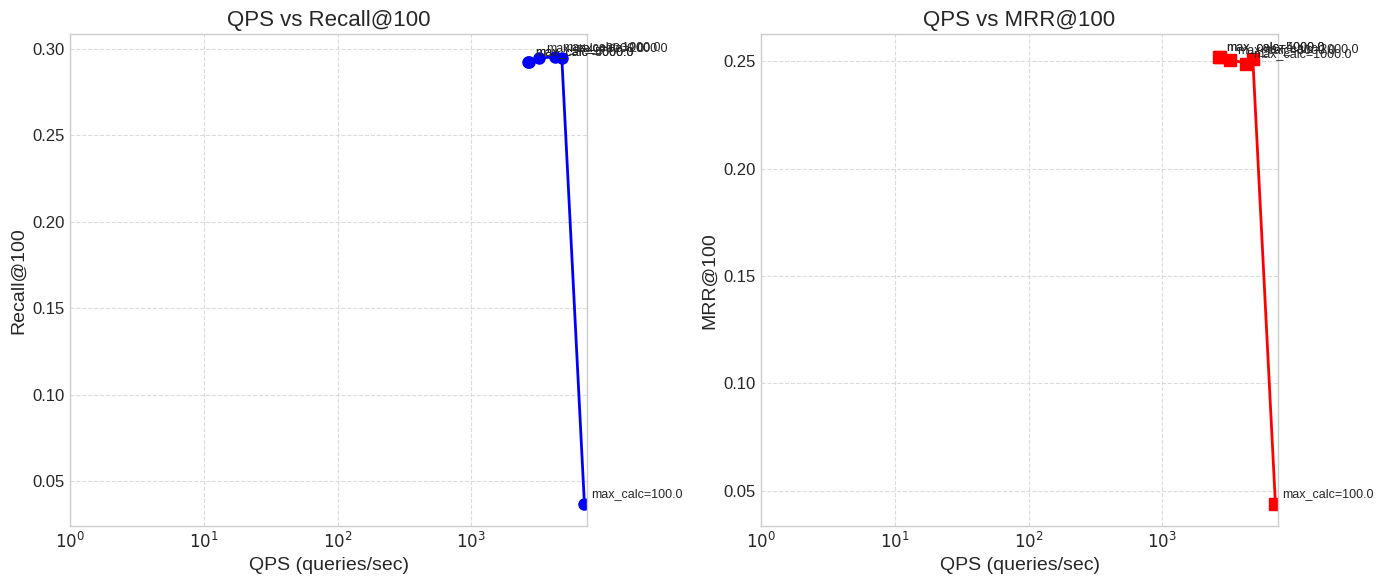

图片已保存为 '/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng/summary.png'


In [6]:
# plot 

plot_qps_metrics("/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng/summary.csv", 
                 topk=100, 
                 max_calc_list=[100, 1000, 2000, 3000, 4000, 5000])

## Fiqa

In [ ]:
cd svr-baselines

# 默认test-embedding顺序与
# gt.ivecs的顺序需与

bash hcnng_fiqa.sh

In [7]:
# summary

extract_hcnng_metrics(base_dir="/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/hcnng")

汇总结果已保存至: /data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/hcnng/summary.csv


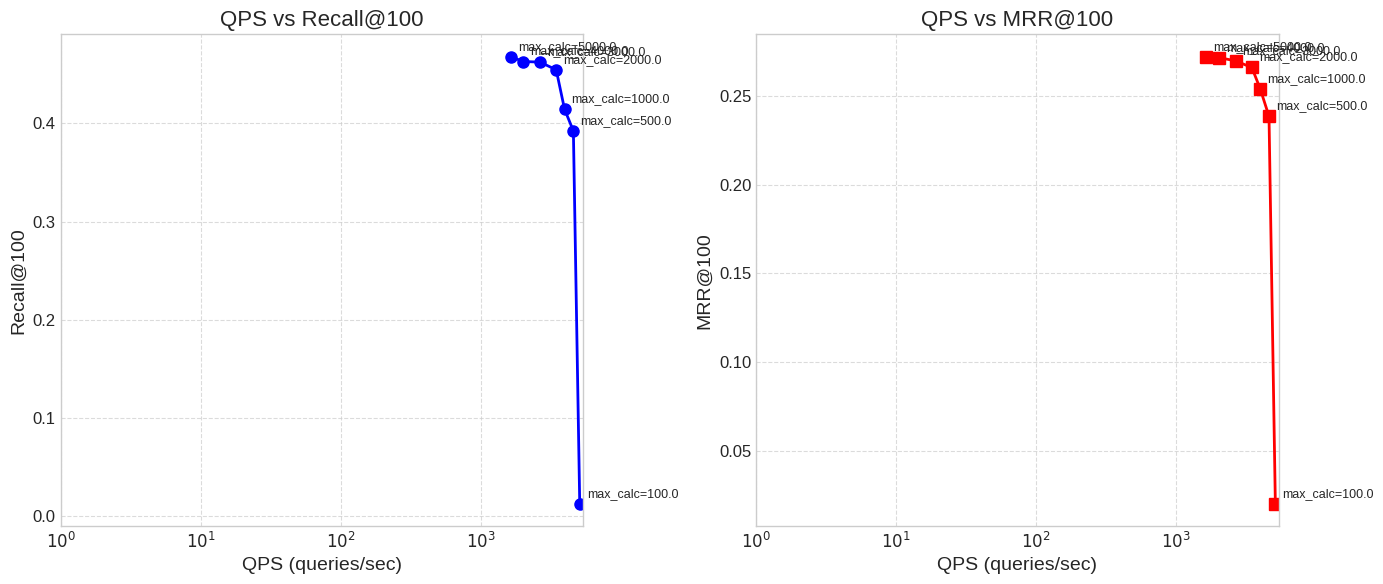

图片已保存为 '/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/hcnng/summary.png'


In [9]:
# plot 

plot_qps_metrics("/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/fiqa-single/hcnng/summary.csv", 
                 topk=100, 
                 max_calc_list=[100, 500, 1000, 2000, 3000, 4000, 5000])